In [1]:
import math
import random
from typing import Dict, List, Tuple
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from src.custom_fastkan import FastKAN

try:
    from scipy.special import lpmv
except ImportError as e:
    raise ImportError(
        "SciPy is required for lpmv(). Install with: pip install scipy"
    ) from e

device = "cpu"
print(f"Using device: {device}")
torch.set_default_dtype(torch.float32)
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

Using device: cpu


In [2]:
# Associated Legendre function dataset (1D): y = P_v^m(x) with fixed m and fixed v
M_ORDER = 1
V_FIXED = 3.0

def true_function_lpmv(x: torch.Tensor, *, v: float = V_FIXED, m: int = M_ORDER) -> torch.Tensor:
    """x has shape (N, 1) (argument in [-1,1]). Returns y = lpmv(m, v, x)."""
    arg = x.squeeze(-1).detach().cpu().numpy()
    v_arr = np.full_like(arg, fill_value=float(v), dtype=np.float64)
    y = lpmv(m, v_arr, arg).astype(np.float64)
    return torch.from_numpy(y).to(x.device, dtype=torch.float32)

num_samples = 20000
x_min, x_max = -0.999, 0.999

X = torch.rand(num_samples, 1) * (x_max - x_min) + x_min  # (N,1) = x

y = true_function_lpmv(X)

# Filter any rare non-finite values
finite_mask = torch.isfinite(y)
X = X[finite_mask]
y = y[finite_mask]
num_samples = X.shape[0]

# Normalize target for easier optimization (metrics will be reported in original scale)
y_mean = y.mean()
y_std = y.std().clamp_min(1e-8)
y_norm = (y - y_mean) / y_std

# Train/val/test split
train_size = int(0.7 * num_samples)
val_size = int(0.15 * num_samples)
test_size = num_samples - train_size - val_size
X_train, X_val, X_test = torch.split(X, [train_size, val_size, test_size])
y_train, y_val, y_test = torch.split(y_norm, [train_size, val_size, test_size])

X_train, y_train = X_train.to(device), y_train.to(device)
X_val, y_val = X_val.to(device), y_val.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

print(f"Dataset: lpmv(m={M_ORDER}, v={V_FIXED}, x)")
print(f"Samples: {num_samples}")
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Target normalization: mean={y_mean.item():.4e}, std={y_std.item():.4e}")

Dataset: lpmv(m=1, v=3.0, x)
Samples: 20000
Train: torch.Size([14000, 1]), Val: torch.Size([3000, 1]), Test: torch.Size([3000, 1])
Target normalization: mean=-3.0560e-01, std=1.2749e+00


In [3]:
from torch.utils.data import DataLoader, TensorDataset

batch_size = 64
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

def denorm(y_hat_norm: torch.Tensor) -> torch.Tensor:
    return y_hat_norm * y_std.to(y_hat_norm.device) + y_mean.to(y_hat_norm.device)

def eval_mse_r2(model: torch.nn.Module, loader: DataLoader) -> Tuple[float, float]:
    model.eval()
    preds = []
    targets = []
    with torch.no_grad():
        for xb, yb in loader:
            yhat = model(xb).squeeze(-1)
            preds.append(denorm(yhat).detach().cpu())
            targets.append(denorm(yb).detach().cpu())
    preds = torch.cat(preds).numpy()
    targets = torch.cat(targets).numpy()
    return float(mean_squared_error(targets, preds)), float(r2_score(targets, preds))

def train_regression(
    model: torch.nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    *,
    lr: float = 1e-3,
    max_epochs: int = 2000,
    patience: int = 200,
) -> Dict[str, object]:
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()
    best_val = float("inf")
    best_state = None
    bad_epochs = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_loss_sum = 0.0
        train_n = 0
        for xb, yb in train_loader:
            optimizer.zero_grad(set_to_none=True)
            yhat = model(xb).squeeze(-1)
            loss = loss_fn(yhat, yb)
            loss.backward()
            optimizer.step()
            train_loss_sum += float(loss.item()) * xb.shape[0]
            train_n += xb.shape[0]
        train_mse_norm = train_loss_sum / max(train_n, 1)

        model.eval()
        val_loss_sum = 0.0
        val_n = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                yhat = model(xb).squeeze(-1)
                loss = loss_fn(yhat, yb)
                val_loss_sum += float(loss.item()) * xb.shape[0]
                val_n += xb.shape[0]
        val_mse_norm = val_loss_sum / max(val_n, 1)

        if val_mse_norm < best_val - 1e-10:
            best_val = val_mse_norm
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        if epoch % 100 == 0 or epoch == 1:
            test_mse, test_r2 = eval_mse_r2(model, test_loader)
            print(
                f"Epoch {epoch:4d} | train(norm MSE)={train_mse_norm:.4e} "
                f"val(norm MSE)={val_mse_norm:.4e} | test(MSE)={test_mse:.4e} r2={test_r2:.4f}"
            )
        history.append((epoch, train_mse_norm, val_mse_norm))

        if bad_epochs >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    final_test_mse, final_test_r2 = eval_mse_r2(model, test_loader)
    return {
        "best_val_mse_norm": best_val,
        "final_test_mse": final_test_mse,
        "final_test_r2": final_test_r2,
        "epochs_ran": epoch,
        "history": history,
    }

In [4]:
def build_mlp(depth: int, width: int, input_dim: int = 1, output_dim: int = 1) -> nn.Module:
    assert depth >= 2
    layers: List[nn.Module] = []
    layers.append(nn.Linear(input_dim, width))
    layers.append(nn.ReLU())
    for _ in range(depth - 2):
        layers.append(nn.Linear(width, width))
        layers.append(nn.ReLU())
    layers.append(nn.Linear(width, output_dim))
    return nn.Sequential(*layers)


def build_kan(depth: int, width: int = 5) -> FastKAN:
    assert depth >= 2
    layers_hidden = [1] + [width] * (depth - 1) + [1]
    return FastKAN(
        layers_hidden,
        grid_min=-1,
        grid_max=1,
        num_grids=10,
        use_base_update=False,
        use_layernorm=False,
    )

# Fixed configs (single run)
KAN_DEPTH = 2
KAN_WIDTH = 5
MLP_DEPTH = 2
MLP_WIDTH = 64

print("Fixed configs (no sweeps):")
print(f"  KAN: depth={KAN_DEPTH}, width={KAN_WIDTH}")
print(f"  MLP: depth={MLP_DEPTH}, width={MLP_WIDTH}")

Fixed configs (no sweeps):
  KAN: depth=2, width=5
  MLP: depth=2, width=64


In [5]:
# Train a single KAN config (no sweep)
print(f"\nTraining KAN depth={KAN_DEPTH}, width={KAN_WIDTH}")
model = build_kan(depth=KAN_DEPTH, width=KAN_WIDTH).to(device)
metrics = train_regression(model, train_loader, val_loader, lr=1e-3, max_epochs=100, patience=200)

best_kan = {
    "depth": KAN_DEPTH,
    "width": KAN_WIDTH,
    "state_dict": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
    **metrics,
}

print("KAN done.")
print(f"  test_mse={best_kan['final_test_mse']:.6e}")
print(f"  test_r2 ={best_kan['final_test_r2']:.6f}")


Training KAN depth=2, width=5
Epoch    1 | train(norm MSE)=2.6357e-01 val(norm MSE)=2.2627e-02 | test(MSE)=3.5359e-02 r2=0.9776
Epoch  100 | train(norm MSE)=6.9630e-05 val(norm MSE)=1.2337e-04 | test(MSE)=1.5278e-04 r2=0.9999
KAN done.
  test_mse=1.559553e-04
  test_r2 =0.999901


In [6]:
# Train a single MLP config (no sweep)
print(f"\nTraining MLP depth={MLP_DEPTH}, width={MLP_WIDTH}")
model = build_mlp(depth=MLP_DEPTH, width=MLP_WIDTH).to(device)
metrics = train_regression(model, train_loader, val_loader, lr=1e-3, max_epochs=200, patience=250)

best_mlp = {
    "depth": MLP_DEPTH,
    "width": MLP_WIDTH,
    "state_dict": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
    **metrics,
}

print("MLP done.")
print(f"  test_mse={best_mlp['final_test_mse']:.6e}")
print(f"  test_r2 ={best_mlp['final_test_r2']:.6f}")


Training MLP depth=2, width=64
Epoch    1 | train(norm MSE)=7.7091e-01 val(norm MSE)=4.4548e-01 | test(MSE)=6.8730e-01 r2=0.5652
Epoch  100 | train(norm MSE)=1.3826e-03 val(norm MSE)=2.2135e-03 | test(MSE)=2.5499e-03 r2=0.9984
Epoch  200 | train(norm MSE)=9.6409e-04 val(norm MSE)=1.5158e-03 | test(MSE)=1.7007e-03 r2=0.9989
MLP done.
  test_mse=1.700671e-03
  test_r2 =0.998924


In [7]:
# Compare the trained single-run models on test set
best_kan_model = build_kan(depth=best_kan["depth"], width=best_kan["width"]).to(device)
best_kan_model.load_state_dict(best_kan["state_dict"])

best_mlp_model = build_mlp(depth=best_mlp["depth"], width=best_mlp["width"]).to(device)
best_mlp_model.load_state_dict(best_mlp["state_dict"])

kan_test_mse, kan_test_r2 = eval_mse_r2(best_kan_model, test_loader)
mlp_test_mse, mlp_test_r2 = eval_mse_r2(best_mlp_model, test_loader)

summary = pd.DataFrame([
    {"model": "KAN", "depth": best_kan["depth"], "width": best_kan["width"], "test_mse": kan_test_mse, "test_r2": kan_test_r2},
    {"model": "MLP", "depth": best_mlp["depth"], "width": best_mlp["width"], "test_mse": mlp_test_mse, "test_r2": mlp_test_r2},
]).sort_values("test_mse")

print("\nSingle-run comparison on lpmv target (original scale):")
display(summary)

ratio = (summary.loc[summary["model"] == "MLP", "test_mse"].values[0] / summary.loc[summary["model"] == "KAN", "test_mse"].values[0])
print(f"\nMLP/KAN test MSE ratio: {ratio:.3f}")


Single-run comparison on lpmv target (original scale):


,model,depth,width,test_mse,test_r2
0,KAN,2,5,0.000156,0.999901
1,MLP,2,64,0.001701,0.998924



MLP/KAN test MSE ratio: 10.905


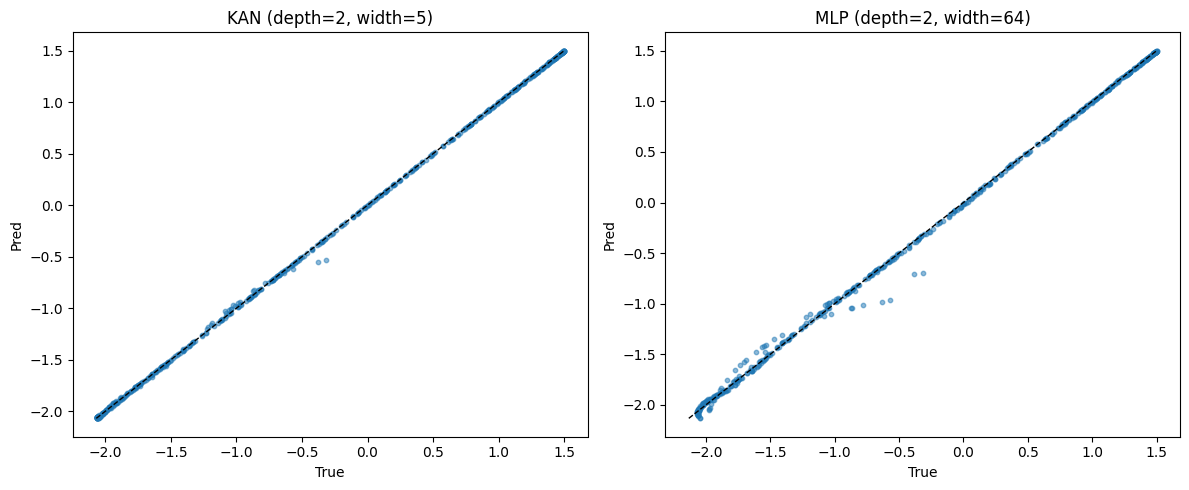

In [8]:
# Visual sanity-check: predicted vs true on a random subset of test points
best_kan_model.eval()
best_mlp_model.eval()

idx = torch.randperm(X_test.shape[0], device=device)[:500]
xb = X_test[idx]
yb_true = denorm(y_test[idx]).detach().cpu().numpy()

with torch.no_grad():
    yb_kan = denorm(best_kan_model(xb).squeeze(-1)).detach().cpu().numpy()
    yb_mlp = denorm(best_mlp_model(xb).squeeze(-1)).detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, yhat, title in [
    (axes[0], yb_kan, f"KAN (depth={best_kan['depth']}, width=5)"),
    (axes[1], yb_mlp, f"MLP (depth={best_mlp['depth']}, width={best_mlp['width']})"),
]:
    ax.scatter(yb_true, yhat, s=10, alpha=0.5)
    mn = float(np.min([yb_true.min(), yhat.min()]))
    mx = float(np.max([yb_true.max(), yhat.max()]))
    ax.plot([mn, mx], [mn, mx], "k--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("True")
    ax.set_ylabel("Pred")
plt.tight_layout()
plt.show()

In [9]:
# (Optional) Print a compact summary
print("\nSummary (single-run):")
print(f"KAN: depth={best_kan['depth']}, width={best_kan['width']}, test_mse={best_kan['final_test_mse']:.6e}, test_r2={best_kan['final_test_r2']:.6f}")
print(f"MLP: depth={best_mlp['depth']}, width={best_mlp['width']}, test_mse={best_mlp['final_test_mse']:.6e}, test_r2={best_mlp['final_test_r2']:.6f}")


Summary (single-run):
KAN: depth=2, width=5, test_mse=1.559553e-04, test_r2=0.999901
MLP: depth=2, width=64, test_mse=1.700671e-03, test_r2=0.998924


In [10]:
# Save MLP model (match other func* notebooks)
mlp_save_path = "model_pkls/functionlegendre_mlp_model.pkl"

# MLP hidden_dims: number of hidden layers = depth - 1
mlp_hidden_dims = [best_mlp["width"]] * (best_mlp["depth"] - 1)

torch.save({
    "model_state_dict": best_mlp["state_dict"],
    "config": {
        "input_dim": 1,
        "hidden_dims": mlp_hidden_dims,
        "output_dim": 1,
    },
}, mlp_save_path)

print(f"MLP Model saved to {mlp_save_path}")

MLP Model saved to model_pkls/functionlegendre_mlp_model.pkl


In [11]:
# Save KAN model (match other func* notebooks)
kan_save_path = "model_pkls/functionlegendre_kan_model.pkl"

layers_hidden = [1] + [best_kan["width"]] * (best_kan["depth"] - 1) + [1]

torch.save({
    "model_state_dict": best_kan["state_dict"],
    "config": {
        "layers_hidden": layers_hidden,
        "grid_min": -1,
        "grid_max": 1,
        "num_grids": 10,
        "use_base_update": False,
        "use_layernorm": False,
    },
}, kan_save_path)

print(f"KAN Model saved to {kan_save_path}")

KAN Model saved to model_pkls/functionlegendre_kan_model.pkl
